In [ ]:
!pip install langgraph

In [ ]:
# 환경 설정 및 라이브러리 설치
!pip install -q openai langchain langchain-openai langchain-community faiss-cpu \
    rank_bm25 pandas numpy matplotlib gradio python-dotenv tiktoken

In [15]:
import os
import operator
from typing import TypedDict, Annotated, Optional, get_type_hints, Literal
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
from langchain_openai import ChatOpenAI
from langchain_core.messages import (
    HumanMessage, AIMessage, SystemMessage, ToolMessage,
)
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
llm = ChatOpenAI(model="gpt-4o-mini")

In [4]:
# 에이전트 -> 직접 코드 짜기도 하고 툴을 호출하거나 중간에 멈추면서 질문을 하거나..
# ReAct: Reasoning + Act

In [16]:
@tool
def add(a:int, b:int) -> int:
  """ 두 정수를 더한다 """
  return a + b

@tool
def multiply(a:int, b:int) -> int:
  """ 두 정수를 곱한다."""
  return a*b

tools = [add, multiply]
llm_with_tools = llm.bind_tools(tools)

In [6]:
# START - agent -> tool_calls 있다면 -> tools -> agent -> ... -> END
                  #  ㄴ 없다면 END

In [17]:
# agent -> tool 호출 -> 답 주거나 다시 agent 호출 -> ...

class AgentState(TypedDict):
  messages : Annotated[list, add_messages] # 리듀서 함수

tool_map = {t.name : t for t in tools}

def agent_node(state):
  return {'messages' : [llm_with_tools.invoke(state['messages'])]}

def tools_node(state):
  out = []
  for c in state['messages'][-1].tool_calls:
    out.append(ToolMessage(content=str(tool_map[c['name']].invoke(c['args'])), tool_call_id = c['id']))

  return {'messages': out}

def should_continue(state):
  return "tools" if state['messages'][-1].tool_calls else END

### agent_node / tools_node / should_continue 설명

**tool_map** —  딕셔너리
- LLM이 도구를 이름(문자열)으로 호출 → 실제 함수 객체가 필요 → 이름-객체 매핑

**agent_node** — LLM이 생각하는 단계
- 메시지 전체를 LLM에 전달 → 두 가지 중 하나 반환:
  - 일반 답변 (도구 불필요) → 에 텍스트
  -  포함 AIMessage → "이 도구를 이 인자로 호출해달라"는 요청
- 리턴값을 리스트로 감싸면  리듀서가 기존 메시지 뒤에 자동 추가

**tools_node** — 도구 실제 실행
-  = agent가 방금 만든 마지막 메시지
- 를 순회하며:
  - 으로 도구 찾기
  - 로 실행
  - 결과를 로 감싸서 반환

**should_continue** — 분기 조건
-  있으면 →  (도구 노드로)
- 없으면 →  (종료)


In [18]:
b = StateGraph(AgentState)
b.add_node('agent', agent_node)
b.add_node('tools', tools_node)

b.add_edge(START, 'agent')
b.add_conditional_edges('agent', should_continue, {'tools': 'tools', END:END}) # 가장 최근 메시지에 tool_calls가 있다면
b.add_edge('tools', 'agent') # 툴을 호출했다면 agent로 계속 감. 호출 안했으면 END

react_app = b.compile()


In [19]:
r = react_app.invoke({'messages': [HumanMessage(content="(3+5)*4 는?")]})

In [20]:
r['messages'][-1].content

'(3 + 5) * 4 = 32입니다.'

In [21]:
[type(m).__name__ for m in r['messages']] # 메시지 흐름

['HumanMessage',
 'AIMessage',
 'ToolMessage',
 'AIMessage',
 'ToolMessage',
 'AIMessage']

In [22]:
# 상태 관리
# prd.md, skills.md

# 셀프 RAG, Self Refinement...
# HITL(휴먼 인 더 루프) 중요한 것 전에 사용자한테 승인을 받도록 하는 로직

In [24]:
@tool
def square(n):
  """정수의 제곱을 반환한다."""
  return n*n

sq_tools = [square]
sq_llm = llm.bind_tools(sq_tools)
sq_map = {t.name:t for t in sq_tools}

In [27]:
class SqState(TypedDict):
  messages : Annotated[list, add_messages]

def sq_agent(state):
  return {'messages' : [sq_llm.invoke(state['messages'])]}

def sq_tn(state):
  return {'messages': [ToolMessage(content = str(sq_map[c['name']].invoke(c['args'])), tool_call_id = c['id']) for c in state['messages'][-1].tool_calls]}

def sq_route(state):
  return 'tools' if state['messages'][-1].tool_calls else END

sb_ = StateGraph(SqState)
sb_.add_node('agent', sq_agent)
sb_.add_node('tools', sq_tn)

sb_.add_edge(START, 'agent')
sb_.add_conditional_edges('agent', sq_route, {'tools': 'tools', END: END})
sb_.add_edge('tools', 'agent')

sq_app = sb_.compile()
result = sq_app.invoke({'messages': [HumanMessage(content = '7의 제곱은?')]})
result['messages'][-1].content

'7의 제곱은 49입니다.'

### ToolNode, ToolCondition

In [29]:
class AgentState(TypedDict):
  messages : Annotated[list, add_messages] # 리듀서 함수

tool_map = {t.name : t for t in tools}

def agent_node(state):
  return {'messages' : [llm_with_tools.invoke(state['messages'])]}

def tools_node(state):
  out = []
  for c in state['messages'][-1].tool_calls:
    out.append(ToolMessage(content=str(tool_map[c['name']].invoke(c['args'])), tool_call_id = c['id']))

  return {'messages': out}

def should_continue(state):
  return "tools" if state['messages'][-1].tool_calls else END

b = StateGraph(AgentState)
b.add_node('agent', agent_node)
b.add_node('tools', tools_node)

b.add_edge(START, 'agent')
b.add_conditional_edges('agent', should_continue, {'tools': 'tools', END:END}) # 가장 최근 메시지에 tool_calls가 있다면
b.add_edge('tools', 'agent') # 툴을 호출했다면 agent로 계속 감. 호출 안했으면 END

react_app = b.compile()


In [38]:
# 툴을 자동으로 찾아서..
b2 = StateGraph(AgentState)
b2.add_node('agent', agent_node)
b2.add_node('tools', ToolNode(tools)) # tools_node 대신 ToolNode

b2.add_edge(START, 'agent')
b2.add_conditional_edges('agent', tools_condition) # should_continue 대신 tools_condition
b2.add_edge('tools', 'agent')
auto_app = b2.compile()

In [39]:
r = auto_app.invoke({'messages': [HumanMessage(content="(3+5)*4 는?")]})

In [40]:
r['messages'][-1].content

'(3 + 5) * 4의 결과는 32입니다.'

In [41]:
for m in r['messages']:
  print(m)
  print()

content='(3+5)*4 는?' additional_kwargs={} response_metadata={} id='3ce05c4d-5384-419a-879e-f9fd0f451da7'

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 78, 'total_tokens': 95, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0628d073e2', 'id': 'chatcmpl-DaK02X96c0dVeGFdeVv5snmPSawT4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019dde2e-206d-7fc1-ab5d-a65a67745ebb-0' tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 5}, 'id': 'call_xgnEHk0GLRKl6EprUmXh2ZL7', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 78, 'output_tokens': 17, 'total_tokens': 95, 'input_token_details': {'audio': 0, 'cache_

 — LangGraph 내장 분기 함수
- 메시지에 가 있으면 →  노드로 이동
- 가 없으면 → (종료)
-  함수를 직접 작성할 필요 없이 동일 동작

In [ ]:
@tool
def substract(a, b):
  """ 두 정수의 차를 구하는 함수입니다."""
  return a-b

tools = [add, multiply, substract]
llm_with_tools = llm.bind_tools(tools)

b2 = StateGraph(AgentState)
b2.add_node('agent', agent_node)
b2.add_node('tools', ToolNode(tools)) # tools_node 대신 ToolNode : tools 자동탐지

b2.add_edge(START, 'agent')
b2.add_conditional_edges('agent', tools_condition) # should_continue 대신 tools_condition
b2.add_edge('tools', 'agent')
auto_app = b2.compile()

r = auto_app.invoke({'messages': [HumanMessage(content="100 - (3+5)*4 는?")]})

In [48]:
r['messages'][-1].content

'계산 결과는 68입니다.'

In [49]:
for m in r['messages']:
  print(m)
  print()

content='100 - (3+5)*4 는?' additional_kwargs={} response_metadata={} id='de6e5c98-f61e-4984-906b-f41bb52f74c3'

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 109, 'total_tokens': 127, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b6580bbee1', 'id': 'chatcmpl-DaK4JfIg1uRA1rg1M35uB0bhCN27V', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019dde32-2a8b-75b3-bb4d-98d23f6d573b-0' tool_calls=[{'name': 'substract', 'args': {'a': 100, 'b': 32}, 'id': 'call_3865K6KhUwQVDUYVObJY6yHL', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 109, 'output_tokens': 18, 'total_tokens': 127, 'input_token_details': {

In [52]:
# 강사님 코드

class ThreeState(TypedDict):
  messages : Annotated[list, add_messages]

tb = StateGraph(ThreeState)
tb.add_node('agent', lambda s: {'messages' : [llm_with_tools.invoke(s['messages'])]})
tb.add_node('tools', ToolNode(tools))

tb.add_edge(START, 'agent')
tb.add_conditional_edges('agent', tools_condition)
tb.add_edge('tools','agent') # 'tool' -> 'tools'로 수정
three_app = tb.compile()

r = three_app.invoke({'messages' : [HumanMessage(content = '100 더하기 5 빼기 2에 3을 곱하면?')]})

print(r['messages'][-1].content) # 검증 로직이 없음..

100 더하기 5는 105이고, 5 빼기 2는 3입니다. 그래서 3에 3을 곱하면 9입니다. 최종 결과는 **9**입니다.


In [53]:
# 법률 에이전트
  # 안녕하세요?            -> 인삿말만 했는데 RAG를 가동하거나.. 하면 안됨 - general한 쿼리
  # 형법 xx조가 뭔가요?    -> 조문 검색
  # 대법원 2021 1222 판례 알려줘   -> 판례 검색
  # {특정 법률 용어} 질문  -> 용어 설명

In [56]:
class QState(TypedDict):
  question : str
  qtype : Literal['article', 'case', 'term', 'general'] # 리터럴이란..? typing 라이브러리
  answer : str

def classify(state: QState) -> dict:
  response = llm.invoke([
      SystemMessage(content = """질문을 다음 4가지 카테고리 중 하나로 분류하세요:

      - article : 법률 조문 (~조, ~항) 에 대한 질문
      - case : 판례 번호 (예: 2022다1234)나 특정 사건
      - term : 법률 용어 정의 및 개념
      - general : 인사, 일상 대화, 기타질문

      답변은 반드시 하나의 단어('article', 'case', 'term', 'general') 로만 하세요.
      """),
      # few_shot_examples로 각 케이스별 예시를 강화해도 됨

      HumanMessage(content = state['question'])
  ])

  qtype = response.content.strip().lower()
  if qtype not in ['article', 'case', 'term', 'general']:
    qtype = 'general' # 예외처리,, 바이브코딩 시 어려움 (방어로직)

  return {'qtype' : qtype}

def article_search(s) : return {'answer': f'[조문 검색] {s['question']}'}
def case_search(s) : return {'answer': f'[판례 검색] {s['question']}'}
def term_search(s) : return {'answer': f'[용어 설명] {s['question']}'}
def general_chat(s) : return {'answer': f'[일반 대화] {s['question']}'}

def route_by_type(state:QState) -> str:
  return state['qtype']


qb = StateGraph(QState)
qb.add_node('classify', classify)
qb.add_node('article', article_search)
qb.add_node('case', case_search)
qb.add_node('general', general_chat)
qb.add_node('term', term_search)

qb.add_edge(START, 'classify')
qb.add_conditional_edges('classify', route_by_type, {'article':'article', 'case':'case', 'term':'term', 'general':'general'})

qb.add_edge('article', END)
qb.add_edge('case', END)
qb.add_edge('term', END)
qb.add_edge('general', END)

q_app = qb.compile()

In [57]:
q_app.invoke({'question':'민법 제760조가 뭔가요?', 'qtype':'general', 'answer':''})

{'question': '민법 제760조가 뭔가요?',
 'qtype': 'case',
 'answer': '[판례 검색] 민법 제760조가 뭔가요?'}

In [58]:
q_app.invoke({'question':'판례란??', 'qtype':'general', 'answer':''})

{'question': '판례란??', 'qtype': 'case', 'answer': '[판례 검색] 판례란??'}

In [80]:
# 실습: 음식 분류 라우터
# korean, western, asian, other


class FoodState(TypedDict):
  question : str
  food_type : Literal['korean', 'western', 'asian', 'other']
  answer : str

def classify(state: FoodState) -> dict:
  response = llm.invoke([
      SystemMessage(content = """사용자가 말한 요리를 다음 4가지 카테고리 중 하나로 분류하세요:

      - korean : 한식
      - western : 이탈리안, 프랑스, 스페인 등
      - asian : 중식, 베트남, 태국
      - other : 기타 음식

      답변은 반드시 하나의 단어('korean', 'western', 'asian', 'other') 로만 하세요.
      """),
      # few_shot_examples로 각 케이스별 예시를 강화해도 됨

      HumanMessage(content = state['question'])
  ])

  ftype = response.content.strip().lower()
  if ftype not in ['korean', 'western', 'asian', 'other']:
      ftype = 'other'

  return {'food_type': ftype}


def korean_food(s):  return {'answer': f'[한식] {s["question"]}'}
def western_food(s): return {'answer': f'[양식] {s["question"]}'}
def asian_food(s):   return {'answer': f'[아시안] {s["question"]}'}
def other_food(s):   return {'answer': f'[기타 음식] {s["question"]}'}


def route_by_type(state: FoodState) -> str:
    return state['food_type']


fb = StateGraph(FoodState)
fb.add_node('classify', classify)
fb.add_node('korean',  korean_food)
fb.add_node('western', western_food)
fb.add_node('asian',   asian_food)
fb.add_node('other',   other_food)

fb.add_edge(START, 'classify')
fb.add_conditional_edges(
    'classify',
    route_by_type,
    {'korean': 'korean', 'western': 'western', 'asian': 'asian', 'other': 'other'}
)

fb.add_edge('korean',  END)
fb.add_edge('western', END)
fb.add_edge('asian',   END)
fb.add_edge('other',   END)

f_app = fb.compile()

In [78]:
f_app.invoke({'question':'쌀국수', 'ftype':'other', 'answer':''})

{'question': '쌀국수', 'food_type': 'asian', 'answer': '[아시안 추천] 쌀국수'}

### 에이전트 기억공간(메모리) 추가
- memory saver

In [81]:
memory = MemorySaver()

In [ ]:

b2 = StateGraph(AgentState)
b2.add_node('agent', agent_node)
b2.add_node('tools', ToolNode(tools)) # tools_node 대신 ToolNode

b2.add_edge(START, 'agent')
b2.add_conditional_edges('agent', tools_condition) # should_continue 대신 tools_condition
b2.add_edge('tools', 'agent')
auto_app = b2.compile()


In [83]:
memory = MemorySaver() # 컨텍스트를 계속 유지하고 싶을 때 사용
mem_app = b2.compile(checkpointer = memory)

In [84]:
cfg = {'configurable': {'thread_id': 'alice'}} # thred_id가 달라지면 다른 사람임
mem_app.invoke({'messages' : [HumanMessage(content = '내 이름은 앨리스야')]}, config=cfg)

{'messages': [HumanMessage(content='내 이름은 앨리스야', additional_kwargs={}, response_metadata={}, id='415bccb9-fecc-447a-aa01-6affa00d0e01'),
  AIMessage(content='안녕하세요, 앨리스! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 106, 'total_tokens': 121, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b6580bbee1', 'id': 'chatcmpl-DaL2PkZ3N6cx4SJYGO3iwsQjag44F', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dde6b-02a9-7190-bfb1-44cdafae139e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 106, 'output_tokens': 15, 'total_tokens': 121, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_detail

In [87]:
r = mem_app.invoke({'messages' : [HumanMessage(content = '내 이름이 뭐였지')]}, config=cfg)

In [89]:
r

{'messages': [HumanMessage(content='내 이름은 앨리스야', additional_kwargs={}, response_metadata={}, id='415bccb9-fecc-447a-aa01-6affa00d0e01'),
  AIMessage(content='안녕하세요, 앨리스! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 106, 'total_tokens': 121, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b6580bbee1', 'id': 'chatcmpl-DaL2PkZ3N6cx4SJYGO3iwsQjag44F', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dde6b-02a9-7190-bfb1-44cdafae139e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 106, 'output_tokens': 15, 'total_tokens': 121, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_detail

In [88]:
len(r['messages'])

8

In [90]:
cfg_bob = {'configurable': {'thread_id': 'bob'}} # thread_id를 다른걸로 설정(새로 시작)하니 기존 이름을 알 수 없다고 함

r = mem_app.invoke({'messages' : [HumanMessage(content = '내 이름이 뭐야?')]}, config = cfg_bob)
r['messages'][-1].content

'죄송하지만, 당신의 이름을 알 수 있는 정보가 없습니다. 당신의 이름을 말씀해 주시면 좋겠습니다!'

In [91]:
prefs = {'u1': '피자', 'u2' : '초밥', 'u3':'떡볶이'}

for uid, food in prefs.items():
  mem_app.invoke({'messages': [HumanMessage(content=f"내가 좋아하는 음식은 {food}야")]}, config = {'configurable': {'thread_id': uid}})

for uid in prefs:
  r = mem_app.invoke({'messages': [HumanMessage(content=f"내가 좋아하는 음식은?")]}, config = {'configurable': {'thread_id': uid}})
  print(f"[{uid}] {r['messages'][-1].content}")

[u1] 당신이 좋아하는 음식은 피자입니다!
[u2] 당신이 말씀하신 바에 따르면, 당신이 좋아하는 음식은 초밥입니다! 추가로 다른 좋아하는 음식이나 스타일이 있다면 알려주세요.
[u3] 당신이 좋아하는 음식은 떡볶이입니다! 매콤하고 맛있는 떡볶이의 매력에 빠진 것 같네요. 다른 좋아하는 음식들도 있나요?


In [92]:
# snapshot 찍음
# AI agent, Agentic AI
  # 어느 state인지, 다음 state는 어디인지 등..

# get_state
cfg_a = {'configurable': {'thread_id': 'alice'}}
snap = mem_app.get_state(cfg_a)

In [93]:
snap # 대화 내역이 snapshot으로 찍혀있음

StateSnapshot(values={'messages': [HumanMessage(content='내 이름은 앨리스야', additional_kwargs={}, response_metadata={}, id='415bccb9-fecc-447a-aa01-6affa00d0e01'), AIMessage(content='안녕하세요, 앨리스! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 106, 'total_tokens': 121, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b6580bbee1', 'id': 'chatcmpl-DaL2PkZ3N6cx4SJYGO3iwsQjag44F', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dde6b-02a9-7190-bfb1-44cdafae139e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 106, 'output_tokens': 15, 'total_tokens': 121, 'input_token_details': {'audio': 0, 'cache_read': 0}, '

In [94]:
len(snap.values['messages'])

8

In [96]:
snap.next # '()' 비어있다면 그래프가 종료됨을 의미

()

In [106]:
history = list(mem_app.get_state_history(cfg_a))

In [ ]:
history

In [107]:
len(history)

12

In [108]:
history[-1].values.get('messages', [])

[]

### update_state
-  graph 실행 흐름을 거치지 않고 외부에서 state를 직접 갱신하는 방법

In [112]:
# update_state

cfg_x = {'configurable' : {'thread_id' : 'manual'}}
mem_app.update_state(cfg_x, {'messages': [HumanMessage(content="안녕!")]})

snap = mem_app.get_state(cfg_x)

In [113]:
snap

StateSnapshot(values={'messages': [HumanMessage(content='안녕!', additional_kwargs={}, response_metadata={}, id='65d13d6b-b98a-4d69-963f-3ff3e44603cd'), HumanMessage(content='안녕!', additional_kwargs={}, response_metadata={}, id='9a108de7-f7e5-47f2-b449-2ede1ad05df8')]}, next=('agent',), config={'configurable': {'thread_id': 'manual', 'checkpoint_ns': '', 'checkpoint_id': '1f144944-a434-647d-8001-c0282ef23070'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-04-30T12:58:31.696678+00:00', parent_config={'configurable': {'thread_id': 'manual', 'checkpoint_ns': '', 'checkpoint_id': '1f144943-0b6e-635e-8000-be9b76b30ca0'}}, tasks=(PregelTask(id='8d9bf5da-deed-c646-3be1-5a65bf1043ab', name='agent', path=('__pregel_pull', 'agent'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [114]:
for m in snap.values['messages']:
  print(type(m).__name__)

HumanMessage
HumanMessage


In [ ]:
[type(m).__name__ for m in snap.values['messages']]

In [116]:
r = mem_app.invoke(None, config = cfg_x)
r['messages']

[HumanMessage(content='안녕!', additional_kwargs={}, response_metadata={}, id='65d13d6b-b98a-4d69-963f-3ff3e44603cd'),
 HumanMessage(content='안녕!', additional_kwargs={}, response_metadata={}, id='9a108de7-f7e5-47f2-b449-2ede1ad05df8'),
 AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 109, 'total_tokens': 121, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b6580bbee1', 'id': 'chatcmpl-DaLIKr153ti44gZiDZIlWdp5WHvZC', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dde7a-131e-75c1-b25d-7bf6d01ddae2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 109, 'output_tokens': 12, 'tot

In [ ]:
r['messages'][-1].content

### interrupt_before — agent 노드 중단
- `interrupt_before=['agent']`로 컴파일하면 agent 노드 진입 전에 그래프가 멈춤
- 아직 LLM을 호출하지 않았으므로 `messages`가 비어 있음
- `next`가 `('agent',)`이면 다음 실행될 노드가 agent임을 의미

In [ ]:
agent_break = b2.compile(checkpointer=MemorySaver(), interrupt_before = ['agent'])
cfg_tmp = {'configurable' : {'thread_id' : 'agent-break'}}
agent_break.invoke({'message' : [HumanMessage(content = '아무거나 물어봄')]}, config = cfg_tmp)
st = agent_break.get_state(cfg_tmp)

In [ ]:
st.next

In [ ]:
st.values['messages']

In [119]:
# interrupt_before

hitl_app = b2.compile(checkpointer=MemorySaver(), interrupt_before = ['tools'])

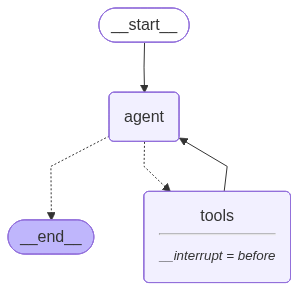

In [120]:
hitl_app

In [121]:
cfg_h = {'configurable' : {'thread_id': 'hitl-1'}}
hitl_app.invoke({'messages': [HumanMessage(content = '100 더하기 200은?')]}, cfg_h)

{'messages': [HumanMessage(content='100 더하기 200은?', additional_kwargs={}, response_metadata={}, id='7efb220b-ba51-4fea-891c-96858743359c'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 106, 'total_tokens': 123, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c6f3b19c71', 'id': 'chatcmpl-DaLNLbnMiZdfEsKBl2CGHNXSl6lER', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dde7e-d663-72c0-a7bc-7e84920c275a-0', tool_calls=[{'name': 'add', 'args': {'a': 100, 'b': 200}, 'id': 'call_sdxlpleffEAN9pV1Mg2ldmMt', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 106, 'output_tokens': 17, 'tot

In [122]:
state = hitl_app.get_state(cfg_h) # get_state는 스냅샷을 찍는 것 (cfg_h)

In [ ]:
state.next

In [ ]:
state

In [125]:
pending = state.values['messages'][-1].tool_calls[0]
pending

{'name': 'add',
 'args': {'a': 100, 'b': 200},
 'id': 'call_sdxlpleffEAN9pV1Mg2ldmMt',
 'type': 'tool_call'}

### HITL 중단 후 재개
- 로 도구 실행 전 멈춘 상태
- 사용자가 pending 내용을 확인한 뒤, 로 이어서 실행
- 을 넘기면 "새 입력 없이 중단된 지점부터 계속"이라는 의미

In [ ]:
# 중단된 상태에서 재개 — None을 넘기면 이어서 실행
result = hitl_app.invoke(None, config=cfg_h)
result

In [ ]:
result['messages'][-1].content

### 정책 거부 (도구 실행 차단)
- `update_state`로 도구 실행 대신 거부 메시지를 직접 주입 가능
- 도구 실행을 승인하지 않는 경우, AIMessage로 거부 사유를 넣으면 LLM이 그대로 반환

In [ ]:
cfg_r = {'configurable' : {'thread_id' : 'reject-test'}}
hitl_app.invoke({'messages' : [HumanMessage(content = '50 곱하기 4는?')]}, config=cfg_r)

# 도구 실행을 거부하고 직접 응답을 주입
hitl_app.update_state(cfg_r, {'messages' : [AIMessage(content='정책상 도구 실행을 거부합니다')]})

# 재개 — update_state로 넣은 메시지가 최종 답변이 됨
r = hitl_app.invoke(None, config=cfg_r)

In [ ]:
r['messages'][-1].content